<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

### 📌 Question  7.2

> Using the 20 years of daily high temperature data for Atlanta (July through October) from Question 6.2 (file temps.txt), build and use an exponential smoothing model to help make a judgment of whether the unofficial end of summer has gotten later over the 20 years.  (Part of the point of this assignment is for you to think about how you might use exponential smoothing to answer this question. Feel free to combine it with other models if you’d like to. There’s certainly more than one reasonable approach.) 

>Note: in R, you can use either HoltWinters (simpler to use) or the smooth package’s es function (harder to use, but more general).  If you use es, the Holt-Winters model uses model=”AAM” in the function call (the first and second constants are used “A”dditively, and the third (seasonality) is used “M”ultiplicatively; the documentation doesn’t make that clear). 


In [ ]:
data_path_temp<-"/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/01_Data/Homework4_ISYE6501/temps.txt"

Temperatures <- read.csv(data_path_temp,header = TRUE,sep = "\t")

Temperatures.columns<-colnames(Temperatures)[-1]
Temperature_transformed_new <- data.frame()   # start empty

for (i in names(Temperatures)[-1]) {      # loop over all cols except Date
  v_1 <- as.factor(Temperatures[[i]])     # temperatures
  v_2 <- as.factor(Temperatures[[1]])     # Date column
  year_val<-substr(i,start=2,stop=5)
  v_3 <- as.factor(rep(year_val, nrow(Temperatures)))  # column name repeated

  Temperature_transformed_new_new <- rbind(
    Temperature_transformed_new,
    data.frame(Date = v_2,
               year = v_3,
               temperature = v_1)
  )
}



Temperature_transformed_new[,"new_Date"]<-rep(NA, nrow(Temperature_transformed_new))


for(i in 1:nrow(Temperature_transformed_new)){
 Temperature_transformed_new[i,"new_Date"]<-paste(Temperature_transformed_new[i,1],Temperature_transformed_new[i,2],sep="-")
}

Temperature_transformed_new[,"new_Date"]<-as.Date(Temperature_transformed_new[,"new_Date"], format="%d-%b-%Y")

View(Temperatures)



DAY,X1996,X1997,X1998,X1999,X2000,X2001,X2002,X2003,X2004,⋯,X2006,X2007,X2008,X2009,X2010,X2011,X2012,X2013,X2014,X2015
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1-Jul,98,86,91,84,89,84,90,73,82,⋯,93,95,85,95,87,92,105,82,90,85
2-Jul,97,90,88,82,91,87,90,81,81,⋯,93,85,87,90,84,94,93,85,93,87
3-Jul,97,93,91,87,93,87,87,87,86,⋯,93,82,91,89,83,95,99,76,87,79
4-Jul,90,91,91,88,95,84,89,86,88,⋯,91,86,90,91,85,92,98,77,84,85
5-Jul,89,84,91,90,96,86,93,80,90,⋯,90,88,88,80,88,90,100,83,86,84
6-Jul,93,84,89,91,96,87,93,84,90,⋯,81,87,82,87,89,90,98,83,87,84
7-Jul,93,75,93,82,96,87,89,87,89,⋯,80,82,88,86,94,94,93,79,89,90
8-Jul,91,87,95,86,91,89,89,90,87,⋯,82,82,90,82,97,94,95,88,90,90
9-Jul,93,84,95,87,96,91,90,89,88,⋯,84,89,89,84,96,91,97,88,90,91


	Base Factor: 0.0004076212 
	Trend Fator: 0 
	Seasonal Fator: 0.1435827 
	Standard Square Error Fator: 256178.9 


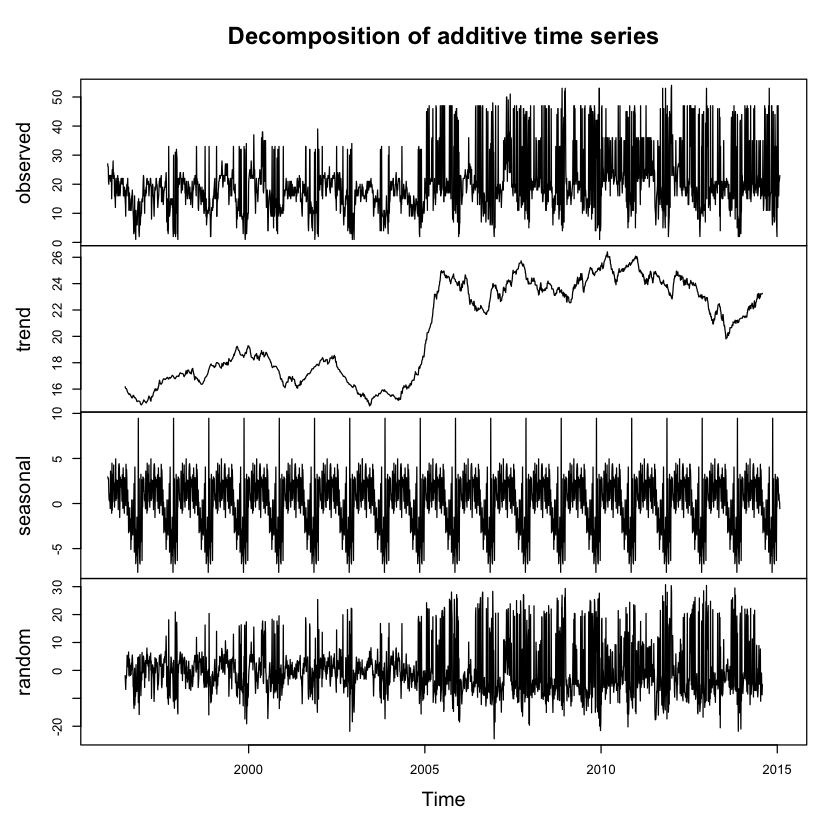

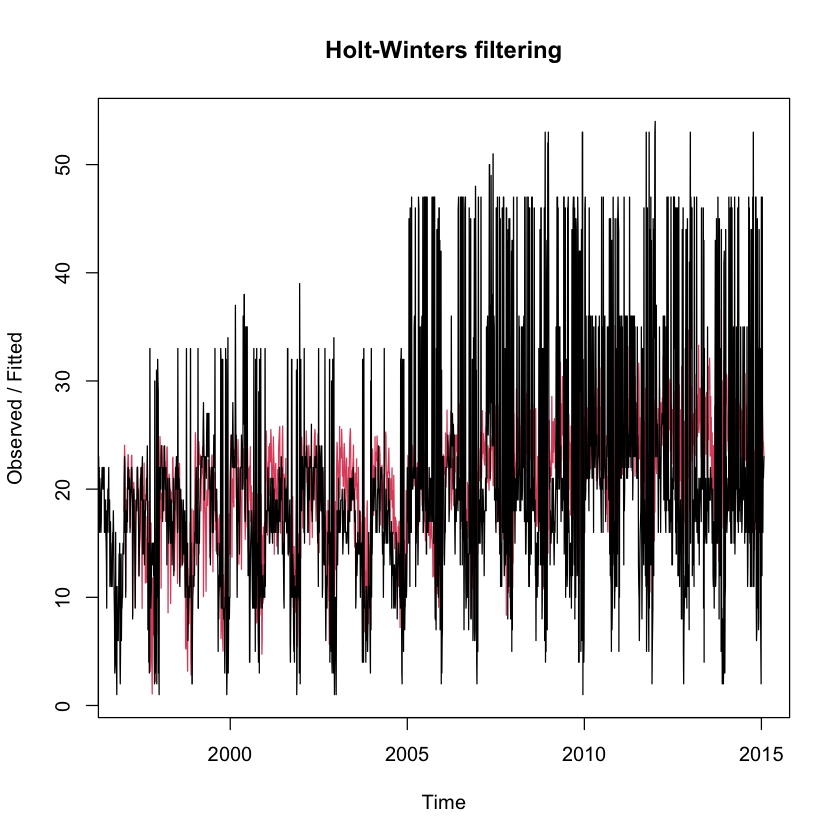

In [ ]:

ts_temps<-ts(data = Temperature_transformed_new$temperature, start = c(1996,1),end=c(2015,10), frequency = 123)

plot(decompose(ts_temps))

Expon_model<-HoltWinters(ts_temps, beta=NULL, gamma=NULL, alpha = NULL, seasonal = "multiplicative")

cat("\tBase Factor:",Expon_model$alpha,"\n")
cat("\tTrend Fator:",Expon_model$beta,"\n")
cat("\tSeasonal Fator:",Expon_model$gamma,"\n")
cat("\tStandard Square Error Fator:",Expon_model$SSE,"\n")

plot(Expon_model)

In [61]:
library(ggplot2)

# Build a data frame with time, actual, and fitted
df_hw <- data.frame(
  time   = as.numeric(time(ts_temps)),
  actual = as.numeric(ts_temps)
)

# HoltWinters$fitted is shorter (starts after initialization), so align it
fitted_hw <- Expon_model$fitted[, "xhat"]
df_hw$fitted <- c(rep(NA, length(df_hw$actual) - length(fitted_hw)),
                  as.numeric(fitted_hw)
                  )

plot_model<-ggplot(df_hw, aes(x = time)) +
  geom_line(aes(y = actual, colour = "Actual")) +
  geom_line(aes(y = fitted, colour = "Fitted")) +
  scale_colour_manual(values = c("Actual" = "black", "Fitted" = "red")) +
  labs(x = "Time", y = "Temperature", colour = "") +
  theme_minimal()

  ggsave("plot.png", plot_model, width = 12, height = 4, units = "in", dpi = 300)

 

Warning message:
“Removed 123 rows containing missing values or values outside the scale range
(`geom_line()`).”


[1] "xhat"   "level"  "trend"  "season"

Warning message in matrix(Expon_model$fitted[, "xhat"], ncol = 123):
“data length [2224] is not a sub-multiple or multiple of the number of rows [19]”


Date,year,temperature
<fct>,<fct>,<fct>
1-Jul,1996,98
2-Jul,1996,97
3-Jul,1996,97
4-Jul,1996,90
5-Jul,1996,89
6-Jul,1996,93
7-Jul,1996,93
8-Jul,1996,91
9-Jul,1996,93


[1] "Left-skewed"
[1] 80
[1] 83.33902
[1] 8.620253
[1] "Year: 1997  Start Date of Alarm: 1997-07-20  End Date of Alarm: 1997-10-15"
[1] "Year: 1998  Start Date of Alarm: 1998-07-10  End Date of Alarm: 1998-10-31"
[1] "Year: 1999  Start Date of Alarm: 1999-07-27  End Date of Alarm: 1999-10-24"
[1] "Year: 2000  Start Date of Alarm: 2000-07-08  End Date of Alarm: 2000-10-31"
[1] "Year: 2001  Start Date of Alarm: 2001-07-26  End Date of Alarm: 2001-10-07"
[1] "Year: 2002  Start Date of Alarm: 2002-07-16  End Date of Alarm: 2002-10-27"
[1] "Year: 2003  Start Date of Alarm: 2003-08-14  End Date of Alarm: 2003-10-01"
[1] "Year: 2004  Start Date of Alarm: 2004-07-21  End Date of Alarm: 2004-10-02"
[1] "Year: 2005  Start Date of Alarm: 2005-07-24  End Date of Alarm: 2005-10-26"
[1] "Year: 2006  Start Date of Alarm: 2006-07-16  End Date of Alarm: 2006-10-24"
[1] "Year: 2007  Start Date of Alarm: 2007-07-29  End Date of Alarm: 2007-10-31"
[1] "Year: 2008  Start Date of Alarm: 2008-07-17  End Date

Warning message:
“Removed 2339 rows containing missing values or values outside the scale range
(`geom_line()`).”


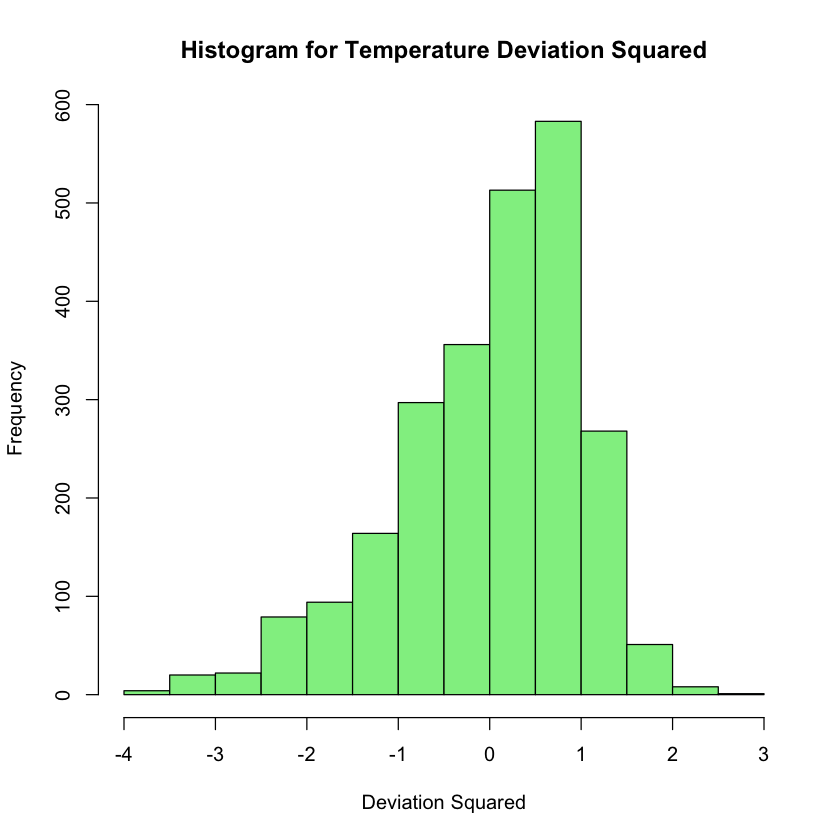

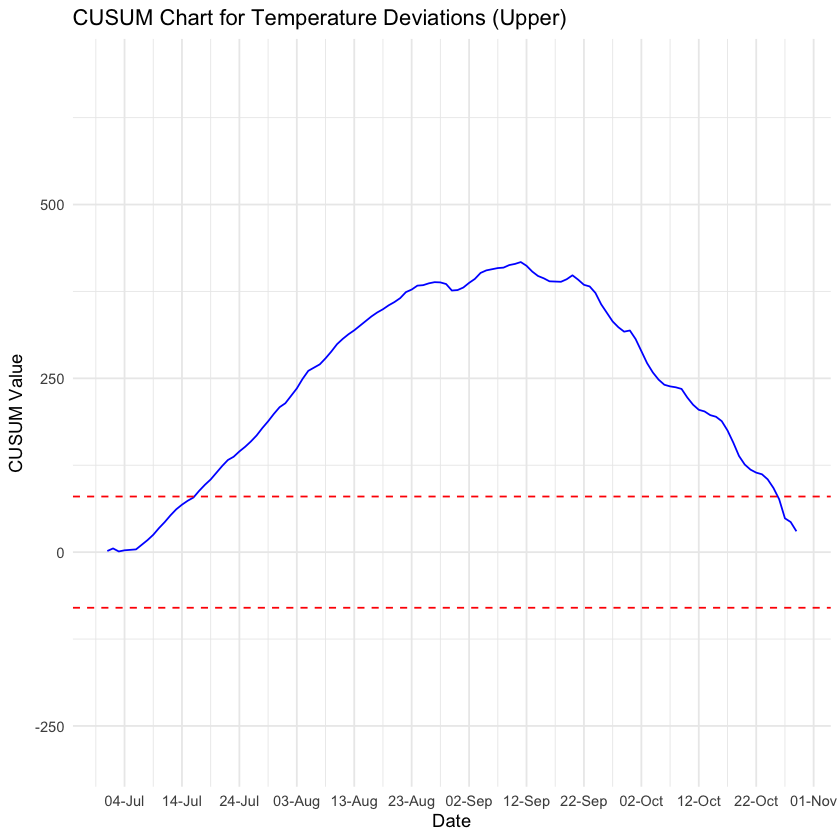

[1] "Year: 1997  Max CUSUM Date: 1997-07-01  Max CUSUM Value: 2.66097560975611  Max Temp: 86"
[1] "Year: 1998  Max CUSUM Date: 1998-07-01  Max CUSUM Value: 7.66097560975611  Max Temp: 91"
[1] "Year: 1999  Max CUSUM Date: 1999-07-01  Max CUSUM Value: 0.660975609756107  Max Temp: 84"
[1] "Year: 2000  Max CUSUM Date: 2000-07-01  Max CUSUM Value: 5.66097560975611  Max Temp: 89"
[1] "Year: 2001  Max CUSUM Date: 2001-07-01  Max CUSUM Value: 0.660975609756107  Max Temp: 84"
[1] "Year: 2002  Max CUSUM Date: 2002-07-01  Max CUSUM Value: 6.66097560975611  Max Temp: 90"
[1] "Year: 2003  Max CUSUM Date: 2003-07-03  Max CUSUM Value: -9.01707317073168  Max Temp: 87"
[1] "Year: 2004  Max CUSUM Date: 2004-07-01  Max CUSUM Value: -1.33902439024389  Max Temp: 82"
[1] "Year: 2005  Max CUSUM Date: 2005-07-01  Max CUSUM Value: 7.66097560975611  Max Temp: 91"
[1] "Year: 2006  Max CUSUM Date: 2006-07-01  Max CUSUM Value: 9.66097560975611  Max Temp: 93"
[1] "Year: 2007  Max CUSUM Date: 2007-07-01  Max CUSUM V

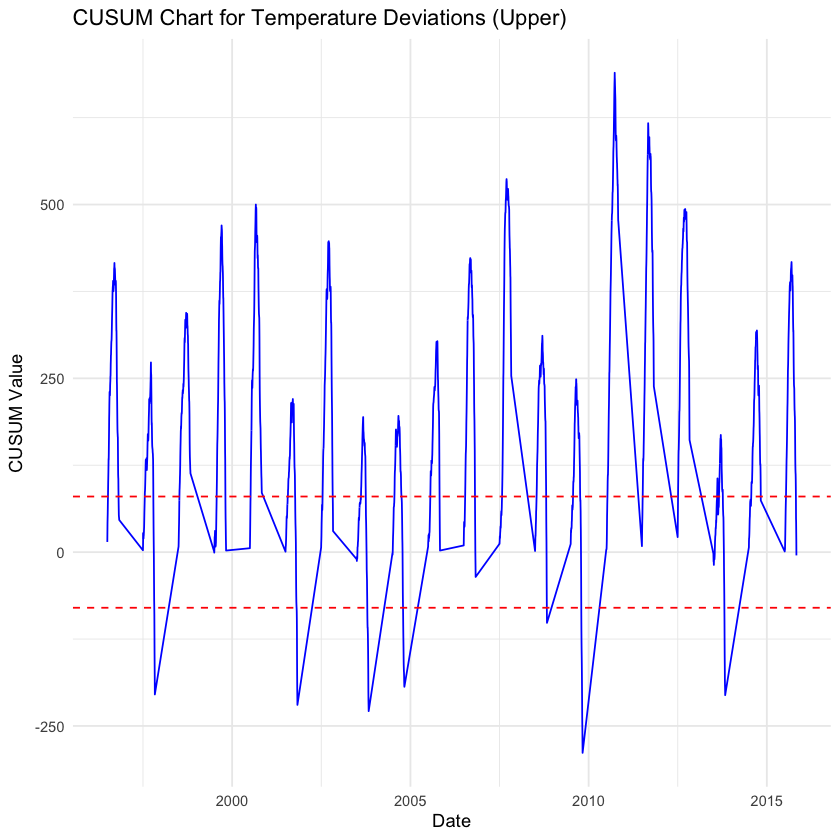

In [90]:
colnames(Expon_model$fitted)

season<-matrix(Expon_model$fitted[,'xhat'],ncol=123)
colnames(season)<-as.vector(t(Temperatures[,1]))
rownames(season)<-c(1997:2015)


season<-t(season)
season<-cbind(rownames(season),season)
rownames(season)<-NULL

Temperatures.columns<-colnames(season)[-1]
Temperature_transformed_new <- data.frame(date= character(),year=character(),temperature=numeric(0.00))   # start empty

for (i in names(Temperatures)[-1]) {      # loop over all cols except Date
  v_1 <- as.factor(Temperatures[[i]])     # temperatures
  v_2 <- as.factor(Temperatures[[1]])     # Date column
  year_val<-substr(i,start=2,stop=5)
  v_3 <- as.factor(rep(year_val, nrow(Temperatures)))  # column name repeated

  Temperature_transformed_new <- rbind(
    Temperature_transformed_new,
    data.frame(Date = v_2,
               year = v_3,
               temperature = v_1)
  )
}

View(Temperature_transformed_new)

Temperature_transformed_new[,"new_Date"]<-rep(NA, nrow(Temperature_transformed_new))


for(i in 1:nrow(Temperature_transformed_new)){
 Temperature_transformed_new[i,"new_Date"]<-paste(Temperature_transformed_new[i,1],Temperature_transformed_new[i,2],sep="-")
}

Temperature_transformed_new[,"new_Date"]<-as.Date(Temperature_transformed_new[,"new_Date"], format="%d-%b-%Y")

Temperature_transformed_new[,"temperature"]<-as.numeric(as.character(Temperature_transformed_new[,"temperature"]))

mu0<-mean(Temperature_transformed_new$temperature)
standard_dev<-sd(Temperature_transformed_new$temperature)


Temperature_transformed_new[,"deviation"]<-as.numeric(Temperature_transformed_new[,"temperature"] - mu0)
Temperature_transformed_new[,"deviation_squared"]<-as.numeric(Temperature_transformed_new[,"deviation"]/standard_dev)

print(if(mean(Temperature_transformed_new$deviation_squared)>median(Temperature_transformed_new$deviation_squared)){"Right-skewed"}else if (mean(Temperature_transformed_new$deviation_squared)<median(Temperature_transformed_new$deviation_squared)){"Left-skewed"}else{"Symmetric"})

hist(Temperature_transformed_new$deviation_squared, main="Histogram for Temperature Deviation Squared", xlab="Deviation Squared", col="lightgreen", border="black")

Temperature_transformed_new[,"AlertUP"]<-rep("NA", nrow(Temperature_transformed_new))
Temperature_transformed_new[,"AlertDOWN"]<-rep("NA", nrow(Temperature_transformed_new))
Temperature_transformed_new[,"SumUP"]<-numeric()
Temperature_transformed_new[,"SumDOWN"]<-numeric()

#######Finnish Data Cleansing and prep ##########

# CUSUM Algorithm Implementation


T<-80
k<-0
mu0<-mean( Temperature_transformed_new$temperature)

print(T)
print(mu0)
print(sd(Temperature_transformed_new$temperature))

for(t in 1:nrow(Temperature_transformed_new)){
  S_plus  <- 0
  S_minus <- 0
  # recursion
    # upper (detect increase in mean)
    if(Temperature_transformed_new[t,"Date"]=="1-Jul"){
      S_plus <- max(0, Temperature_transformed_new[t,"temperature"] -mu0 - k)
      S_minus <- max(0, mu0 - k- Temperature_transformed_new[t,"temperature"]  )
      Temperature_transformed_new[t,"SumUP"]<-Temperature_transformed_new[t,"temperature"] -mu0 - k

      Temperature_transformed_new[t,"SumDOWN"]<-mu0 - k- Temperature_transformed_new[t,"temperature"]

    }
    else {
      S_plus  <- max(0,Temperature_transformed_new[t-1,"SumUP"] + (Temperature_transformed_new[t,"temperature"] -mu0 - k))
      # lower (detect decrease in mean)
      S_minus <- max(0,  Temperature_transformed_new[t-1,"SumDOWN"] + (mu0-k-Temperature_transformed_new[t,"temperature"]))

      Temperature_transformed_new[t,"SumUP"]<-Temperature_transformed_new[t-1,"SumUP"] + (Temperature_transformed_new[t,"temperature"] -mu0 - k)

      Temperature_transformed_new[t,"SumDOWN"]<-Temperature_transformed_new[t-1,"SumDOWN"] + (mu0-k-Temperature_transformed_new[t,"temperature"])
    }

    # check alarms
   if (S_plus > T ) {
      Temperature_transformed_new[t,"AlertUP"] <- TRUE
    } else if(S_minus < -T) {
      Temperature_transformed_new[t,"AlertDOWN"] <- FALSE
    }

}
years_Data<-c("1997",	"1998",	"1999",	"2000",	"2001",	"2002",	"2003",	"2004",	"2005",	"2006",	"2007",	"2008",	"2009",	"2010",	"2011",	"2012",	"2013",	"2014",	"2015")

for(i in years_Data){
  data_temp<-Temperature_transformed_new[Temperature_transformed_new$year==i & Temperature_transformed_new$AlertUP==TRUE,]
  rownames(data_temp) <- NULL
  start_Date<-data_temp[1,"new_Date"]
  end_Date<-data_temp[nrow(data_temp),"new_Date"]
  print(paste("Year:",i," Start Date of Alarm:",start_Date," End Date of Alarm:",end_Date))
}

ggplot(Temperature_transformed_new, aes(x = new_Date, y = SumUP)) +
  geom_line(color = "blue") +

  geom_hline(yintercept = -T, linetype = "dashed", color = "red") +
  geom_hline(yintercept = T, linetype = "dashed", color = "red") +
  labs(
    title = "CUSUM Chart for Temperature Deviations (Upper)",
    x = "Date",
    y = "CUSUM Value"
  ) +
  scale_x_date(
    limits      = as.Date(c("2015-07-01", "2015-10-29")),  # your range
    date_breaks = "10 days",                               # or "1 day"
    date_labels = "%d-%b"                                  # e.g. "01-Jul"
  ) +
  theme_minimal()


  ggplot(Temperature_transformed_new, aes(x = new_Date, y = SumUP)) +
  geom_line(color = "blue") +

  geom_hline(yintercept = -T, linetype = "dashed", color = "red") +
  geom_hline(yintercept = T, linetype = "dashed", color = "red") +
  labs(
    title = "CUSUM Chart for Temperature Deviations (Upper)",
    x = "Date",
    y = "CUSUM Value"
  ) +
  theme_minimal()

  max <-max(Temperature_transformed_new$SumUP)
for(i in years_Data){
  data_max_temp<-Temperature_transformed_new[Temperature_transformed_new[,"year"]==i,]
  max_temp_year<-mean(data_max_temp$temperature)
  data_max_temp<-data_max_temp[data_max_temp$temperature>max_temp_year,]


rownames(data_max_temp)<-NULL
print(paste("Year:",i," Max CUSUM Date:",data_max_temp[1,"new_Date"]," Max CUSUM Value:",data_max_temp[1,"SumUP"]," Max Temp:",data_max_temp[1,"temperature"]))

}

#colname